<a href="https://www.kaggle.com/code/lalit7881/amazon-tech-trends-sales-insights-2026-eda?scriptVersionId=319503922" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/aminasalamt/amazon-tech-trends-and-sales-insights-2026/Amazon_Big_Sales_Dataset_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/aminasalamt/amazon-tech-trends-and-sales-insights-2026/Amazon_Big_Sales_Dataset_2026.csv")

In [3]:
df.head()

,Product_ID,Product_Name,Category,Price_USD,Rating,Review_Count
0,AZ1001,Power Bank Model-39,Audio,591.53,4.1,4399
1,AZ1002,External SSD Model-20,Accessories,647.02,3.6,9779
2,AZ1003,Smart Watch Model-72,Accessories,419.88,4.7,9704
3,AZ1004,Graphics Card Model-97,Electronics,214.91,4.8,6305
4,AZ1005,Mechanical Keyboard Model-53,Computers,1002.45,4.1,8880


In [4]:
df.tail()

,Product_ID,Product_Name,Category,Price_USD,Rating,Review_Count
95,AZ1096,USB-C Hub Model-39,Accessories,441.43,4.9,2072
96,AZ1097,Webcam Pro Model-65,Computers,188.85,3.8,2074
97,AZ1098,USB-C Hub Model-83,Audio,47.43,3.6,3840
98,AZ1099,External SSD Model-31,Computers,1040.16,4.4,7714
99,AZ1100,4K Monitor Model-49,Electronics,727.54,4.7,3528


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_ID    100 non-null    object 
 1   Product_Name  100 non-null    object 
 2   Category      100 non-null    object 
 3   Price_USD     100 non-null    float64
 4   Rating        100 non-null    float64
 5   Review_Count  100 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 4.8+ KB


In [6]:
df.describe()

,Price_USD,Rating,Review_Count
count,100.000000,100.000000,100.000000
mean,738.974900,4.289000,4834.210000
std,415.807278,0.438983,2767.290471
min,23.230000,3.500000,266.000000
25%,410.757500,4.000000,2666.000000
50%,689.010000,4.300000,4463.000000
75%,1117.355000,4.700000,7308.500000
max,1476.800000,5.000000,9953.000000


In [7]:
df.isnull().sum()

Product_ID      0
Product_Name    0
Category        0
Price_USD       0
Rating          0
Review_Count    0
dtype: int64

In [8]:
df.isnull()

,Product_ID,Product_Name,Category,Price_USD,Rating,Review_Count
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,False,False,False,False,False,False
3,False,False,False,False,False,False
4,False,False,False,False,False,False
...,...,...,...,...,...,...
95,False,False,False,False,False,False
96,False,False,False,False,False,False
97,False,False,False,False,False,False
98,False,False,False,False,False,False


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Product_ID       object
Product_Name     object
Category         object
Price_USD       float64
Rating          float64
Review_Count      int64
dtype: object

In [11]:
df.columns

Index(['Product_ID', 'Product_Name', 'Category', 'Price_USD', 'Rating',
       'Review_Count'],
      dtype='object')

In [12]:
df.nunique()

Product_ID      100
Product_Name     94
Category          4
Price_USD       100
Rating           16
Review_Count     99
dtype: int64

In [13]:
df.shape

(100, 6)

## EDA

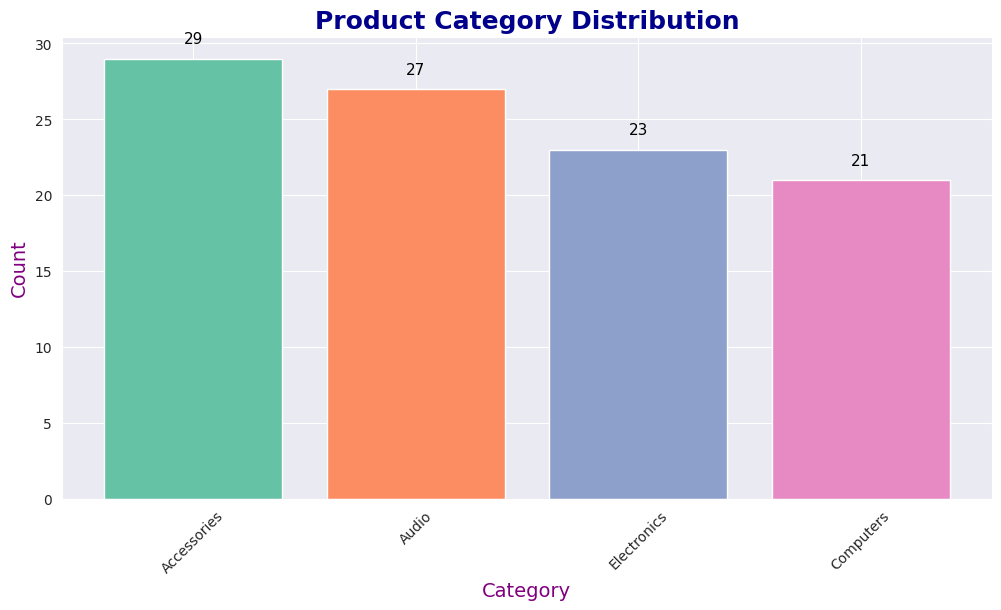

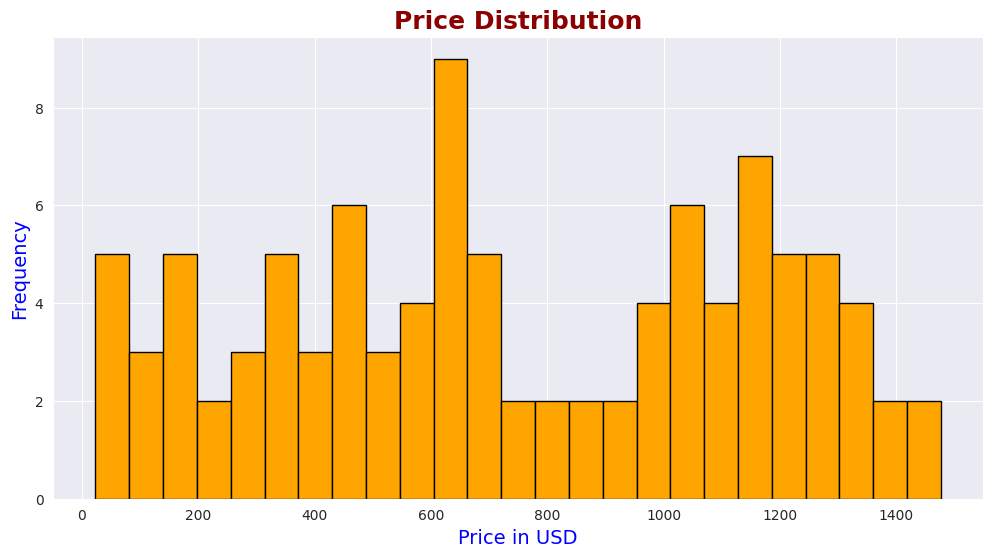

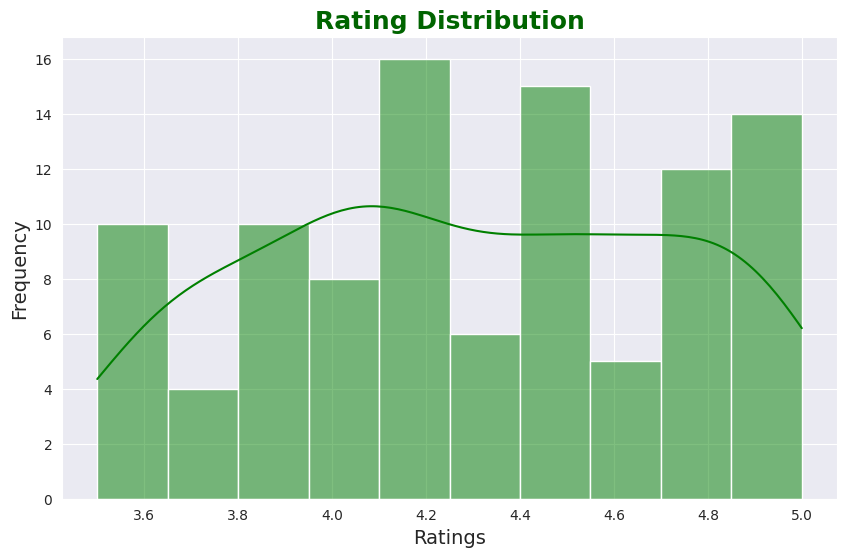

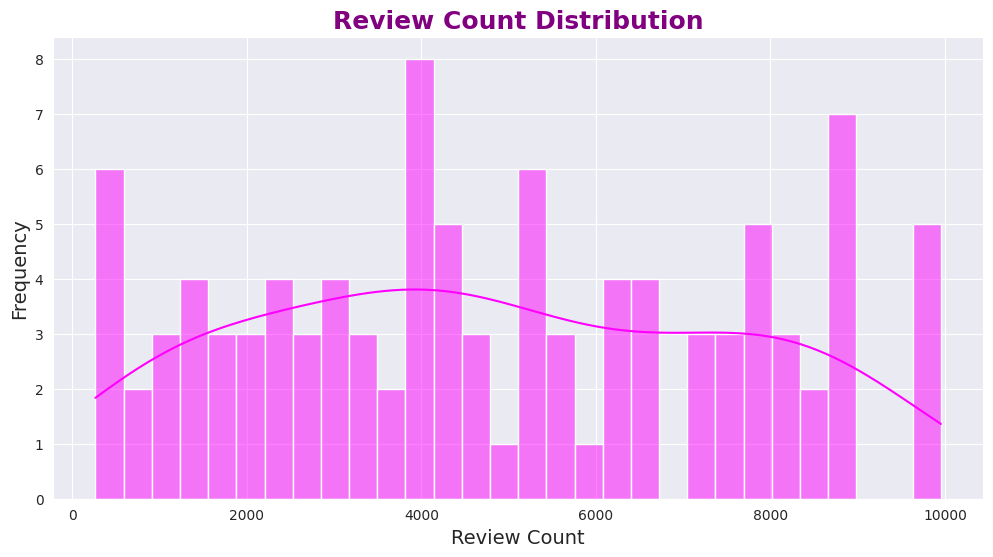

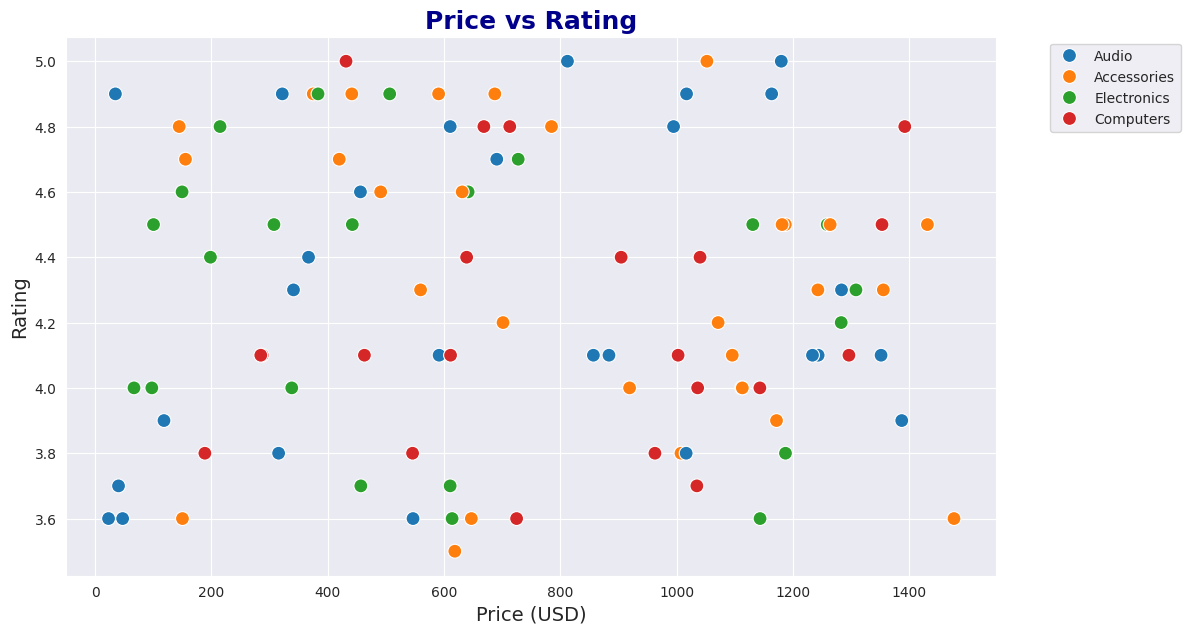

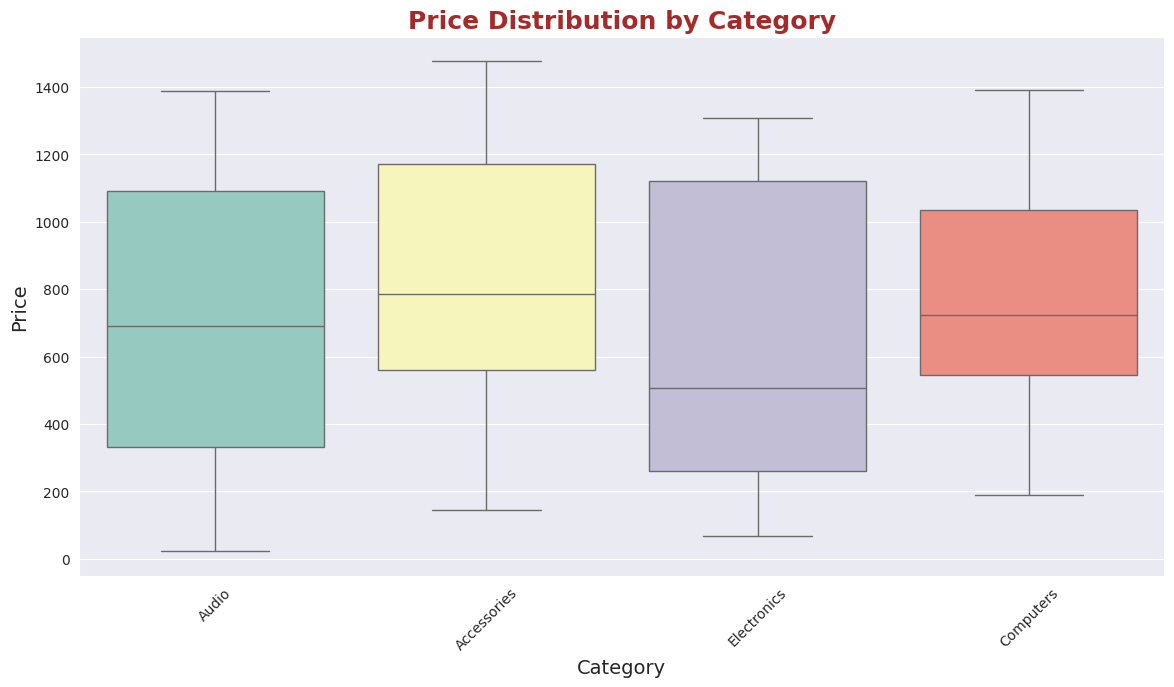

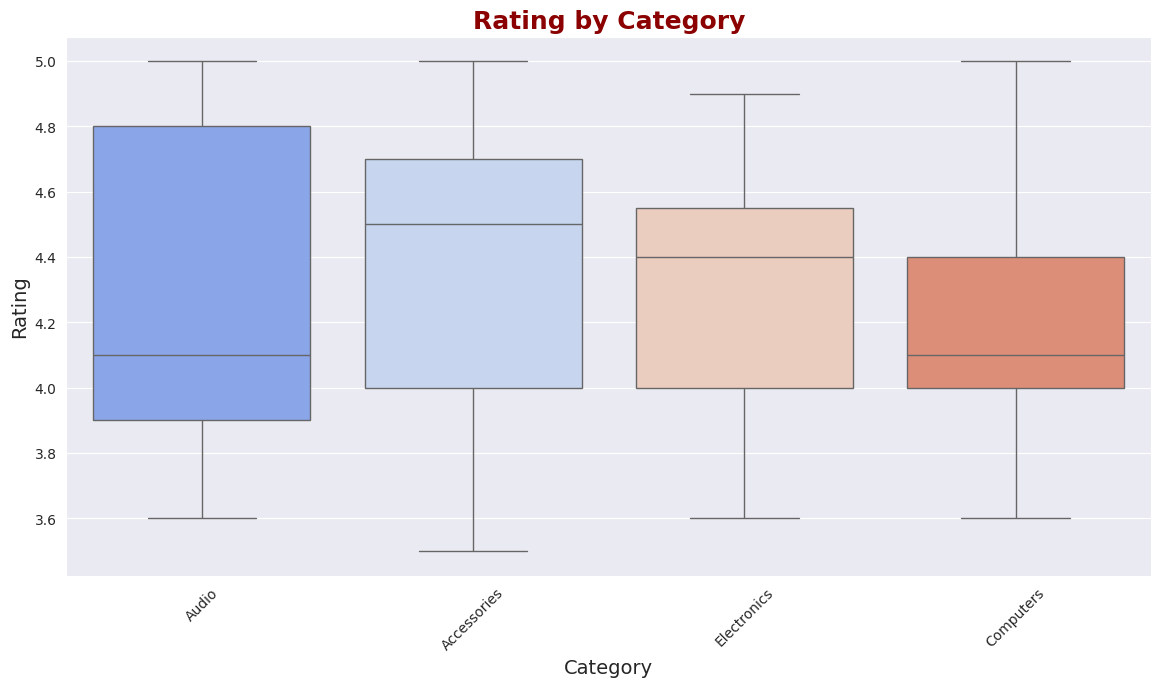

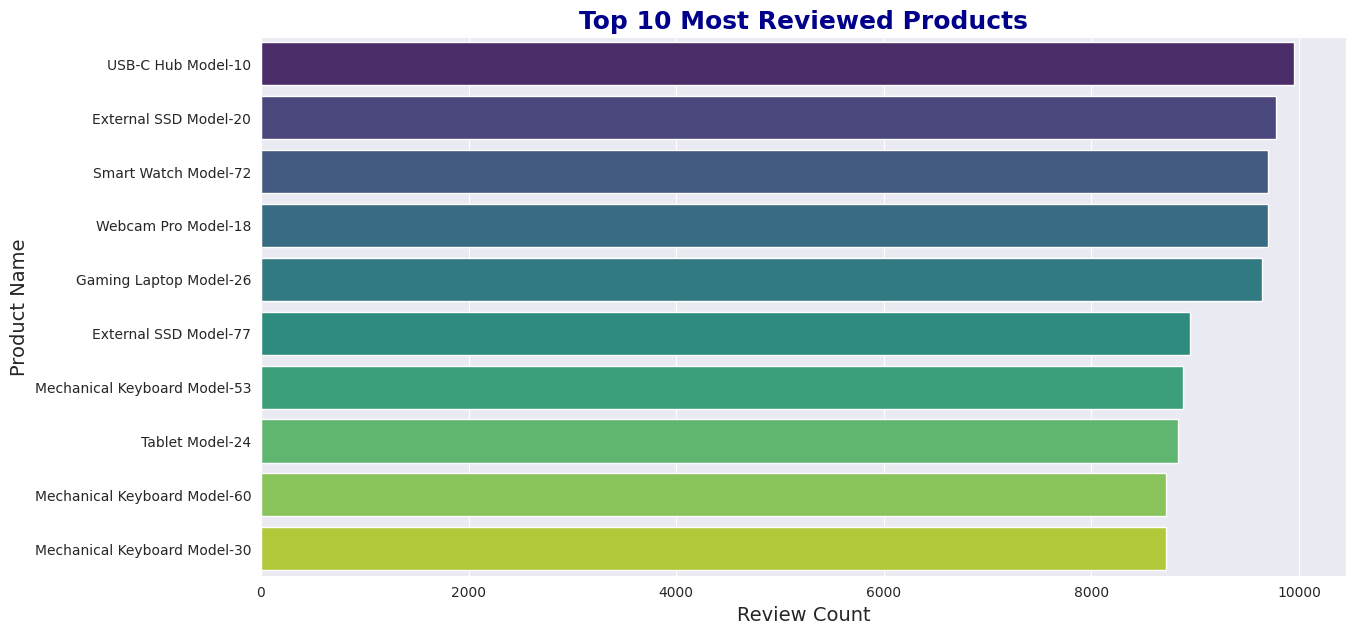

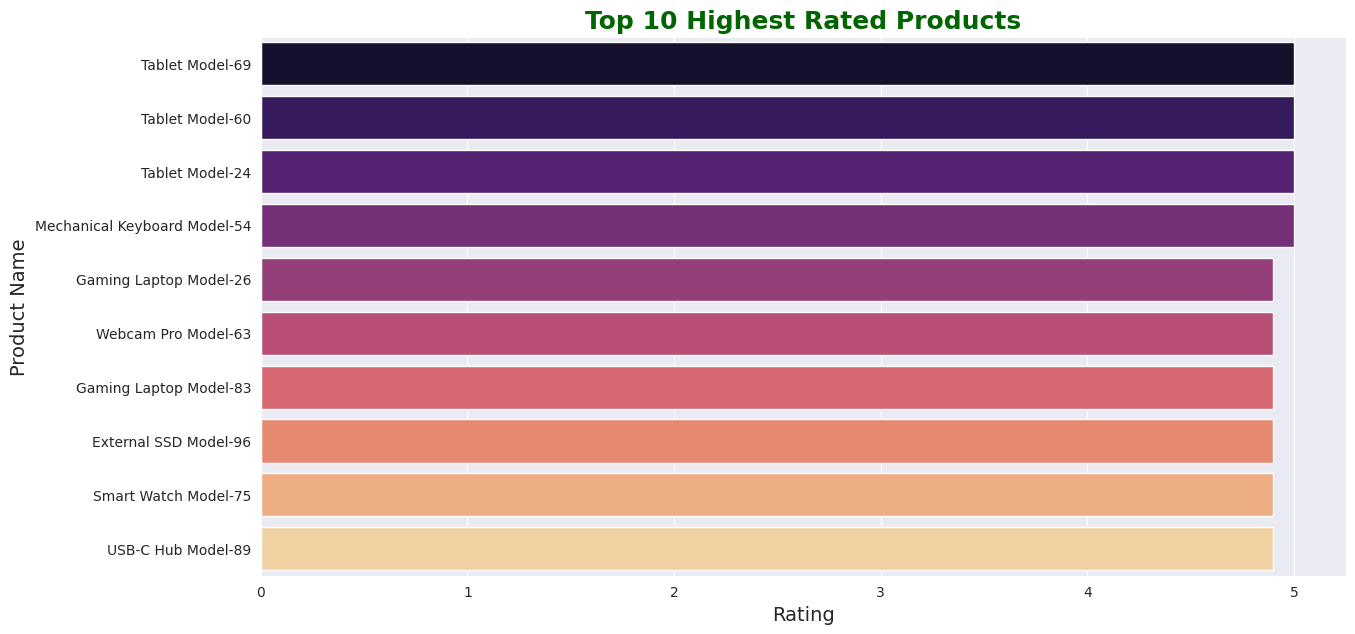

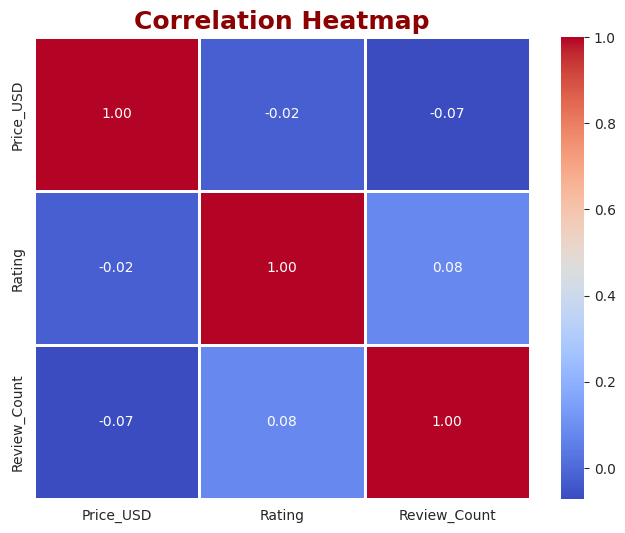

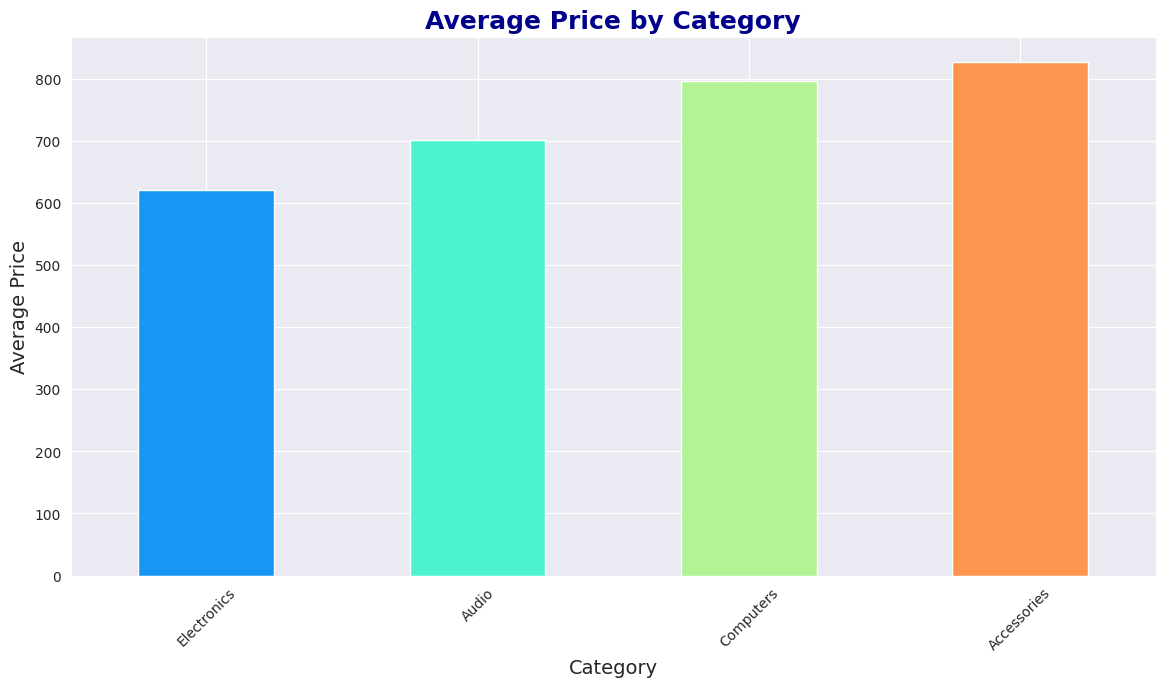

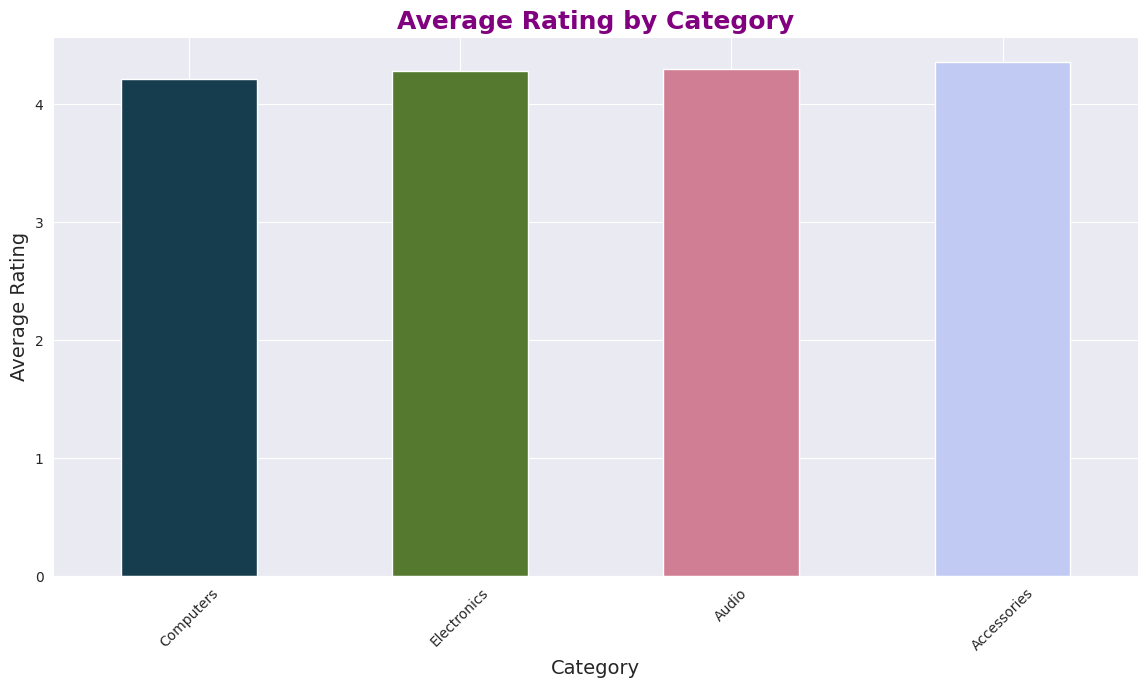

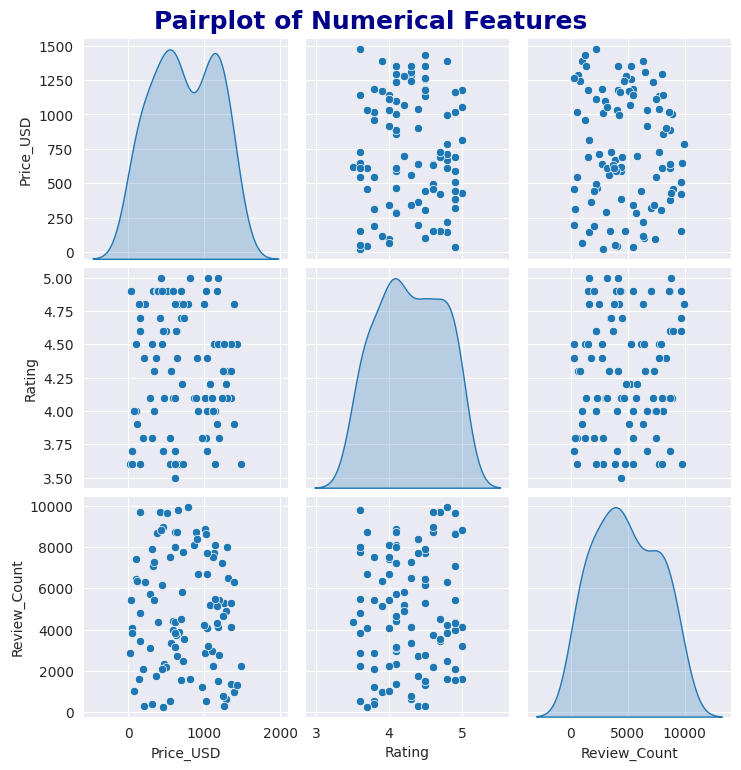

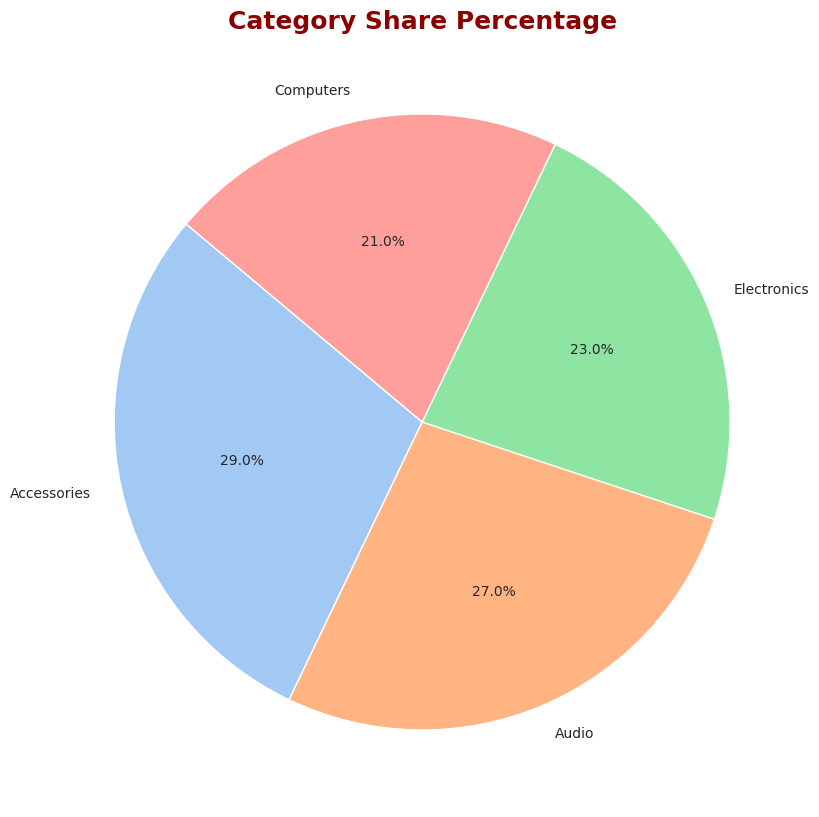


 ALL DATA VISUALIZATIONS COMPLETED SUCCESSFULLY 


In [14]:
# =========================================================
# SET VISUAL STYLE
# =========================================================

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (10,6)

# =========================================================
# 1. CATEGORY DISTRIBUTION
# =========================================================

plt.figure(figsize=(12,6))

category_counts = df['Category'].value_counts()

colors = sns.color_palette('Set2', len(category_counts))

plt.bar(category_counts.index,
        category_counts.values,
        color=colors)

plt.title("Product Category Distribution",
          fontsize=18,
          fontweight='bold',
          color='darkblue')

plt.xlabel("Category",
           fontsize=14,
           color='purple')

plt.ylabel("Count",
           fontsize=14,
           color='purple')

plt.xticks(rotation=45)

for i, v in enumerate(category_counts.values):
    plt.text(i, v+1, str(v),
             ha='center',
             fontsize=11,
             color='black')

plt.show()

# =========================================================
# 2. PRICE DISTRIBUTION HISTOGRAM
# =========================================================

plt.figure(figsize=(12,6))

plt.hist(df['Price_USD'],
         bins=25,
         color='orange',
         edgecolor='black')

plt.title("Price Distribution",
          fontsize=18,
          fontweight='bold',
          color='darkred')

plt.xlabel("Price in USD",
           fontsize=14,
           color='blue')

plt.ylabel("Frequency",
           fontsize=14,
           color='blue')

plt.show()

# =========================================================
# 3. RATING DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(df['Rating'],
             bins=10,
             kde=True,
             color='green')

plt.title("Rating Distribution",
          fontsize=18,
          fontweight='bold',
          color='darkgreen')

plt.xlabel("Ratings",
           fontsize=14)

plt.ylabel("Frequency",
           fontsize=14)

plt.show()

# =========================================================
# 4. REVIEW COUNT DISTRIBUTION
# =========================================================

plt.figure(figsize=(12,6))

sns.histplot(df['Review_Count'],
             bins=30,
             color='magenta',
             kde=True)

plt.title("Review Count Distribution",
          fontsize=18,
          fontweight='bold',
          color='purple')

plt.xlabel("Review Count",
           fontsize=14)

plt.ylabel("Frequency",
           fontsize=14)

plt.show()

# =========================================================
# 5. PRICE VS RATING SCATTER PLOT
# =========================================================

plt.figure(figsize=(12,7))

sns.scatterplot(x='Price_USD',
                y='Rating',
                hue='Category',
                data=df,
                palette='tab10',
                s=100)

plt.title("Price vs Rating",
          fontsize=18,
          fontweight='bold',
          color='darkblue')

plt.xlabel("Price (USD)",
           fontsize=14)

plt.ylabel("Rating",
           fontsize=14)

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.show()

# =========================================================
# 6. PRICE BY CATEGORY - BOXPLOT
# =========================================================

plt.figure(figsize=(14,7))

sns.boxplot(x='Category',
            y='Price_USD',
            data=df,
            palette='Set3')

plt.title("Price Distribution by Category",
          fontsize=18,
          fontweight='bold',
          color='brown')

plt.xlabel("Category",
           fontsize=14)

plt.ylabel("Price",
           fontsize=14)

plt.xticks(rotation=45)

plt.show()

# =========================================================
# 7. RATING BY CATEGORY
# =========================================================

plt.figure(figsize=(14,7))

sns.boxplot(x='Category',
            y='Rating',
            data=df,
            palette='coolwarm')

plt.title("Rating by Category",
          fontsize=18,
          fontweight='bold',
          color='darkred')

plt.xlabel("Category",
           fontsize=14)

plt.ylabel("Rating",
           fontsize=14)

plt.xticks(rotation=45)

plt.show()

# =========================================================
# 8. TOP 10 MOST REVIEWED PRODUCTS
# =========================================================

top_reviewed = df.sort_values(by='Review_Count',
                              ascending=False).head(10)

plt.figure(figsize=(14,7))

sns.barplot(x='Review_Count',
            y='Product_Name',
            data=top_reviewed,
            palette='viridis')

plt.title("Top 10 Most Reviewed Products",
          fontsize=18,
          fontweight='bold',
          color='darkblue')

plt.xlabel("Review Count",
           fontsize=14)

plt.ylabel("Product Name",
           fontsize=14)

plt.show()

# =========================================================
# 9. TOP 10 HIGHEST RATED PRODUCTS
# =========================================================

top_rated = df.sort_values(by='Rating',
                           ascending=False).head(10)

plt.figure(figsize=(14,7))

sns.barplot(x='Rating',
            y='Product_Name',
            data=top_rated,
            palette='magma')

plt.title("Top 10 Highest Rated Products",
          fontsize=18,
          fontweight='bold',
          color='darkgreen')

plt.xlabel("Rating",
           fontsize=14)

plt.ylabel("Product Name",
           fontsize=14)

plt.show()

# =========================================================
# 10. CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(8,6))

correlation = df[['Price_USD',
                  'Rating',
                  'Review_Count']].corr()

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            linewidths=1,
            fmt='.2f')

plt.title("Correlation Heatmap",
          fontsize=18,
          fontweight='bold',
          color='darkred')

plt.show()

# =========================================================
# 11. CATEGORY WISE AVERAGE PRICE
# =========================================================

avg_price = df.groupby('Category')['Price_USD'].mean().sort_values()

plt.figure(figsize=(14,7))

avg_price.plot(kind='bar',
               color=sns.color_palette('rainbow',
               len(avg_price)))

plt.title("Average Price by Category",
          fontsize=18,
          fontweight='bold',
          color='darkblue')

plt.xlabel("Category",
           fontsize=14)

plt.ylabel("Average Price",
           fontsize=14)

plt.xticks(rotation=45)

plt.show()

# =========================================================
# 12. CATEGORY WISE AVERAGE RATING
# =========================================================

avg_rating = df.groupby('Category')['Rating'].mean().sort_values()

plt.figure(figsize=(14,7))

avg_rating.plot(kind='bar',
                color=sns.color_palette('cubehelix',
                len(avg_rating)))

plt.title("Average Rating by Category",
          fontsize=18,
          fontweight='bold',
          color='purple')

plt.xlabel("Category",
           fontsize=14)

plt.ylabel("Average Rating",
           fontsize=14)

plt.xticks(rotation=45)

plt.show()

# =========================================================
# 13. PAIRPLOT
# =========================================================

sns.pairplot(df[['Price_USD',
                 'Rating',
                 'Review_Count']],
             diag_kind='kde',
             palette='husl')

plt.suptitle("Pairplot of Numerical Features",
             fontsize=18,
             fontweight='bold',
             color='darkblue',
             y=1.02)

plt.show()

# =========================================================
# 14. PIE CHART OF CATEGORY DISTRIBUTION
# =========================================================

plt.figure(figsize=(10,10))

category_counts.plot(kind='pie',
                     autopct='%1.1f%%',
                     colors=sns.color_palette('pastel'),
                     startangle=140)

plt.title("Category Share Percentage",
          fontsize=18,
          fontweight='bold',
          color='darkred')

plt.ylabel("")

plt.show()

# =========================================================
# FINAL MESSAGE
# =========================================================

print("\n=================================================")
print(" ALL DATA VISUALIZATIONS COMPLETED SUCCESSFULLY ")
print("=================================================")

## Feature engineering


 CATEGORICAL COLUMNS 

Index(['Product_Name'], dtype='object')

 TRAIN DATA TYPES 

Product_Name      int64
Price_USD       float64
Rating          float64
Review_Count      int64
dtype: object

 TRAIN TEST SHAPES 

X_train Shape : (80, 4)
X_test Shape  : (20, 4)
y_train Shape : (80,)
y_test Shape  : (20,)

 MODEL : Logistic Regression

Accuracy Score : 0.3000

 CLASSIFICATION REPORT 

              precision    recall  f1-score   support

           0       1.00      0.17      0.29         6
           1       0.38      0.60      0.46         5
           2       0.18      0.50      0.27         4
           3       0.00      0.00      0.00         5

    accuracy                           0.30        20
   macro avg       0.39      0.32      0.25        20
weighted avg       0.43      0.30      0.25        20



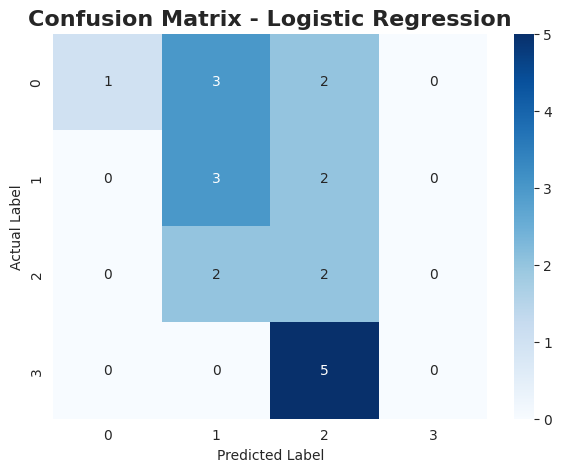


 MODEL : Decision Tree

Accuracy Score : 0.3000

 CLASSIFICATION REPORT 

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.23      0.60      0.33         5
           2       0.00      0.00      0.00         4
           3       0.43      0.60      0.50         5

    accuracy                           0.30        20
   macro avg       0.16      0.30      0.21        20
weighted avg       0.16      0.30      0.21        20



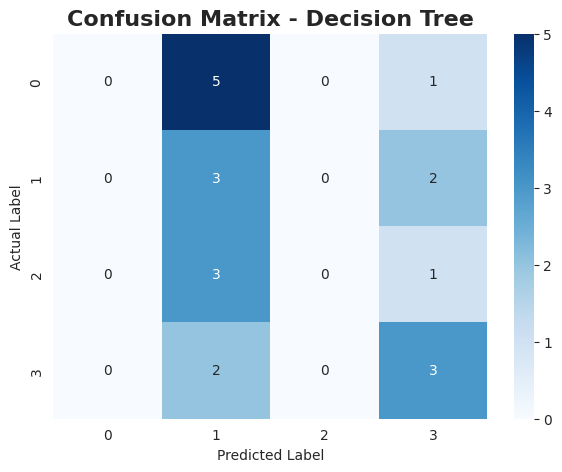


 MODEL : Random Forest

Accuracy Score : 0.2000

 CLASSIFICATION REPORT 

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.24      0.80      0.36         5
           2       0.00      0.00      0.00         4
           3       0.00      0.00      0.00         5

    accuracy                           0.20        20
   macro avg       0.06      0.20      0.09        20
weighted avg       0.06      0.20      0.09        20



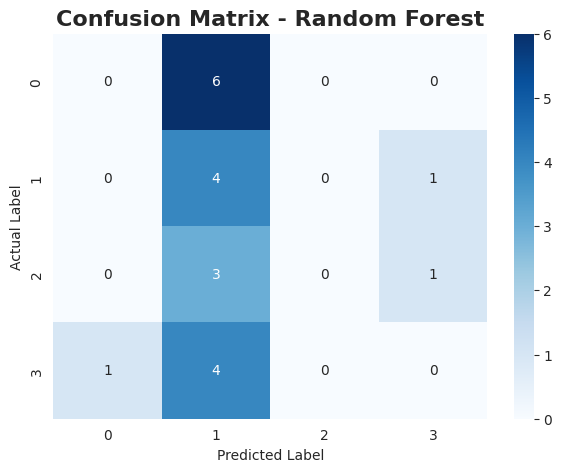


 MODEL : KNN

Accuracy Score : 0.3500

 CLASSIFICATION REPORT 

              precision    recall  f1-score   support

           0       0.44      0.67      0.53         6
           1       0.20      0.20      0.20         5
           2       1.00      0.25      0.40         4
           3       0.20      0.20      0.20         5

    accuracy                           0.35        20
   macro avg       0.46      0.33      0.33        20
weighted avg       0.43      0.35      0.34        20



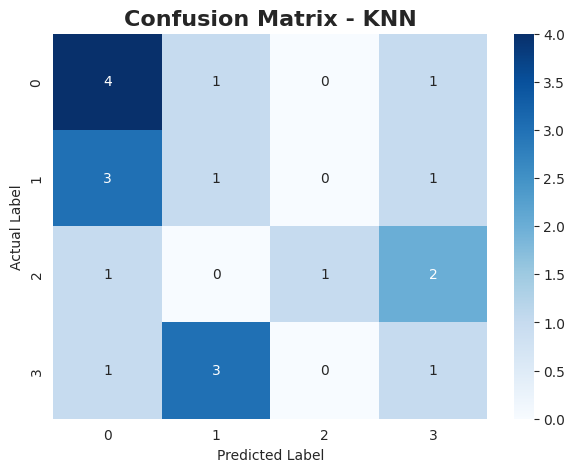


 BEST MODEL 

Best Model : KNN
Best Accuracy : 0.35

 MODEL ACCURACY COMPARISON 

                 Model  Accuracy
0  Logistic Regression      0.30
1        Decision Tree      0.30
2        Random Forest      0.20
3                  KNN      0.35


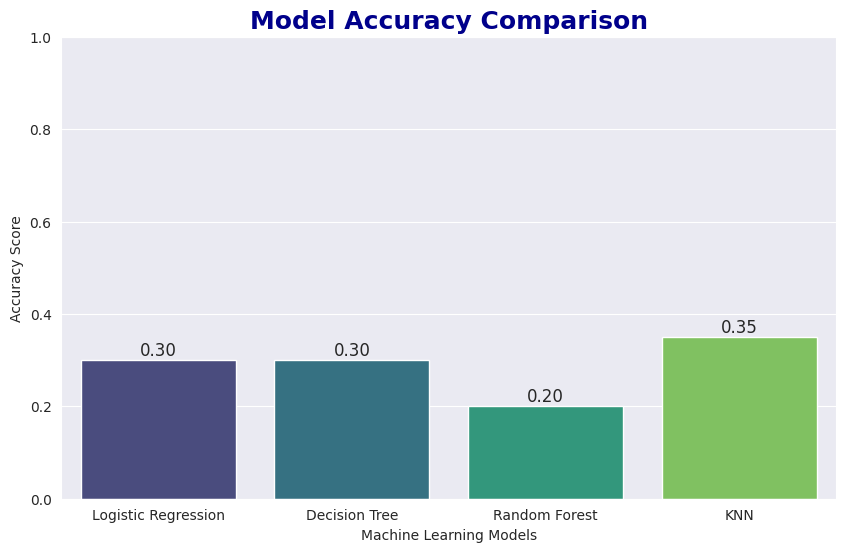

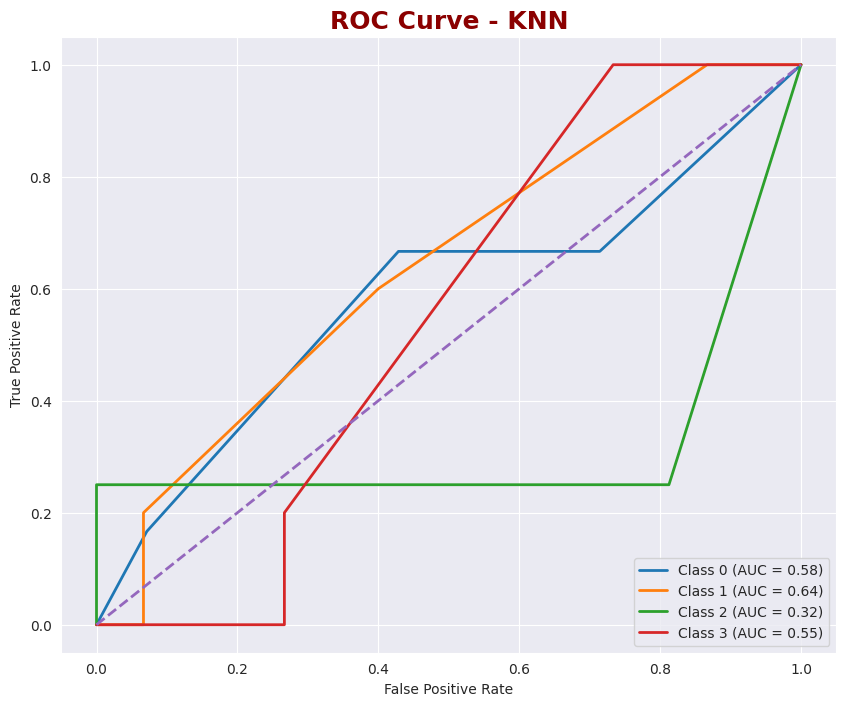


 FEATURE IMPORTANCE 

        Feature  Importance
3  Review_Count    0.288839
0  Product_Name    0.267583
1     Price_USD    0.263423
2        Rating    0.180155


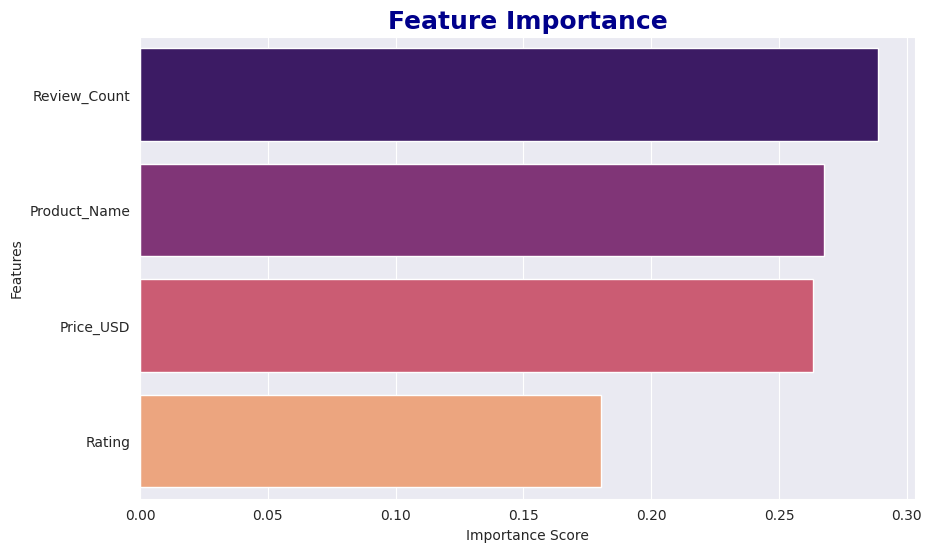


 MACHINE LEARNING PIPELINE COMPLETED 



In [15]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Label Encoding
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import label_binarize

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')


df.drop_duplicates(inplace=True)

# =========================================================
# DROP PRODUCT_ID
# =========================================================
# Product_ID has no predictive power
# =========================================================

if 'Product_ID' in df.columns:
    
    df.drop('Product_ID', axis=1, inplace=True)

# =========================================================
# FEATURES & TARGET
# =========================================================

X = df.drop('Category', axis=1)

y = df['Category']

# =========================================================
# TRAIN TEST SPLIT
# =========================================================
# SPLIT BEFORE ENCODING
# Prevents Data Leakage
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.20,
    
    random_state=42,
    
    stratify=y
    
)

# =========================================================
# LABEL ENCODING FOR FEATURES
# =========================================================

feature_encoders = {}

categorical_columns = X_train.select_dtypes(
    include=['object']
).columns

print("\n=================================================")
print(" CATEGORICAL COLUMNS ")
print("=================================================\n")

print(categorical_columns)

# =========================================================
# ENCODE TRAIN & TEST DATA
# =========================================================

for col in categorical_columns:
    
    le = LabelEncoder()
    
    # Fit on train
    X_train[col] = le.fit_transform(
        X_train[col].astype(str)
    )
    
    # Convert test to string
    X_test[col] = X_test[col].astype(str)
    
    # Handle unseen labels safely
    unseen_labels = set(X_test[col]) - set(le.classes_)
    
    for label in unseen_labels:
        le.classes_ = np.append(le.classes_, label)
    
    # Transform test
    X_test[col] = le.transform(X_test[col])
    
    feature_encoders[col] = le

# =========================================================
# ENCODE TARGET
# =========================================================

target_encoder = LabelEncoder()

y_train = target_encoder.fit_transform(y_train)

# Handle unseen target labels safely
y_test = y_test.astype(str)

unseen_target = set(y_test) - set(target_encoder.classes_)

for label in unseen_target:
    target_encoder.classes_ = np.append(
        target_encoder.classes_,
        label
    )

y_test = target_encoder.transform(y_test)

# =========================================================
# VERIFY DATA TYPES
# =========================================================

print("\n=================================================")
print(" TRAIN DATA TYPES ")
print("=================================================\n")

print(X_train.dtypes)

# =========================================================
# TRAIN TEST SHAPES
# =========================================================

print("\n=================================================")
print(" TRAIN TEST SHAPES ")
print("=================================================\n")

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)

# =========================================================
# MACHINE LEARNING MODELS
# =========================================================

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=5,
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=5
        )
}

# =========================================================
# STORE RESULTS
# =========================================================

results = {}

# =========================================================
# TRAIN & EVALUATE MODELS
# =========================================================

for model_name, model in models.items():

    print("\n=================================================")
    print(f" MODEL : {model_name}")
    print("=================================================\n")

    # =====================================================
    # TRAIN MODEL
    # =====================================================

    model.fit(X_train, y_train)

    # =====================================================
    # PREDICTIONS
    # =====================================================

    y_pred = model.predict(X_test)

    # =====================================================
    # ACCURACY
    # =====================================================

    accuracy = accuracy_score(y_test, y_pred)

    results[model_name] = accuracy

    print(f"Accuracy Score : {accuracy:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    print("\n=================================================")
    print(" CLASSIFICATION REPORT ")
    print("=================================================\n")

    print(classification_report(y_test, y_pred))

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(7,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues'
    )

    plt.title(
        f"Confusion Matrix - {model_name}",
        fontsize=16,
        fontweight='bold'
    )

    plt.xlabel("Predicted Label")
    plt.ylabel("Actual Label")

    plt.show()

# =========================================================
# BEST MODEL
# =========================================================

best_model_name = max(results, key=results.get)

best_accuracy = results[best_model_name]

print("\n=================================================")
print(" BEST MODEL ")
print("=================================================\n")

print("Best Model :", best_model_name)

print("Best Accuracy :", round(best_accuracy, 4))

# =========================================================
# ACCURACY COMPARISON TABLE
# =========================================================

accuracy_df = pd.DataFrame({

    'Model': results.keys(),
    
    'Accuracy': results.values()

})

print("\n=================================================")
print(" MODEL ACCURACY COMPARISON ")
print("=================================================\n")

print(accuracy_df)

# =========================================================
# ACCURACY BAR CHART
# =========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Model',
    y='Accuracy',
    data=accuracy_df,
    palette='viridis'
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=18,
    fontweight='bold',
    color='darkblue'
)

plt.xlabel("Machine Learning Models")
plt.ylabel("Accuracy Score")

plt.ylim(0,1)

# Add labels
for index, value in enumerate(accuracy_df['Accuracy']):
    
    plt.text(
        index,
        value + 0.01,
        f"{value:.2f}",
        ha='center',
        fontsize=12
    )

plt.show()

# =========================================================
# ROC CURVE
# =========================================================
# MULTI-CLASS ROC CURVE
# =========================================================

best_model = models[best_model_name]

# =========================================================
# BINARIZE TARGET
# =========================================================

classes = np.unique(y_train)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

n_classes = y_test_bin.shape[1]

# =========================================================
# PREDICT PROBABILITIES
# =========================================================

y_score = best_model.predict_proba(X_test)

# =========================================================
# PLOT ROC CURVE
# =========================================================

plt.figure(figsize=(10,8))

for i in range(n_classes):

    fpr, tpr, threshold = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'Class {i} (AUC = {roc_auc:.2f})'
    )

# Random Guess Line
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    lw=2
)

plt.title(
    f"ROC Curve - {best_model_name}",
    fontsize=18,
    fontweight='bold',
    color='darkred'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend(loc='lower right')

plt.show()

# =========================================================
# FEATURE IMPORTANCE
# =========================================================
# ONLY FOR RANDOM FOREST
# =========================================================

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

importance = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({

    'Feature': X_train.columns,
    
    'Importance': importance

})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\n=================================================")
print(" FEATURE IMPORTANCE ")
print("=================================================\n")

print(feature_importance_df)

# =========================================================
# FEATURE IMPORTANCE VISUALIZATION
# =========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df,
    palette='magma'
)

plt.title(
    "Feature Importance",
    fontsize=18,
    fontweight='bold',
    color='darkblue'
)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n=================================================")
print(" MACHINE LEARNING PIPELINE COMPLETED ")
print("=================================================\n")